In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import nltk
import re
import string

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [2]:
#Step 2: Upload the dataset
from google.colab import files

uploaded = files.upload()

Saving moviereviews.csv to moviereviews.csv


In [3]:
df = pd.read_csv("moviereviews.csv")

In [4]:
#View Dataset
df.head()

,index,label,review
0,0,neg,how do films like mouse hunt get into theatres...
1,1,neg,some talented actresses are blessed with a dem...
2,2,pos,this has been an extraordinary year for austra...
3,3,pos,according to hollywood movies made in last few...
4,4,neg,my first press screening of 1998 and already i...


In [5]:
df.shape

(2000, 3)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   index   2000 non-null   int64 
 1   label   2000 non-null   object
 2   review  1965 non-null   object
dtypes: int64(1), object(2)
memory usage: 47.0+ KB


In [7]:
df.describe()

,index
count,2000.000000
mean,999.500000
std,577.494589
min,0.000000
25%,499.750000
50%,999.500000
75%,1499.250000
max,1999.000000


In [8]:
#Check Missing Values
df.isnull().sum()

,0
index,0
label,0
review,35


In [9]:
#Remove Duplicates
df = df.drop_duplicates()

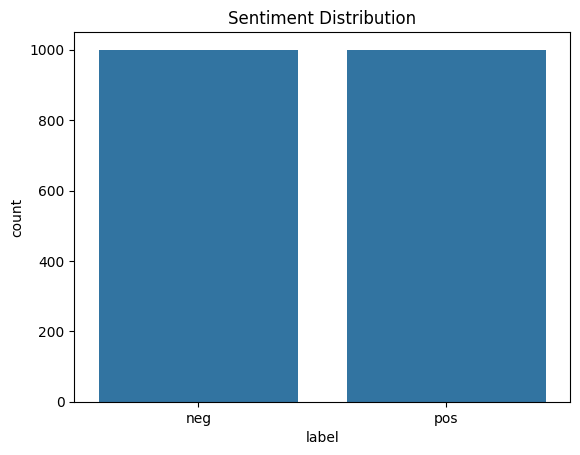

In [10]:
#Sentiment Distribution
sns.countplot(x='label', data=df)

plt.title("Sentiment Distribution")

plt.show()

In [11]:
#Review Length
df['Review_Length'] = df['review'].fillna('').apply(len)

In [13]:
df.head()

,index,label,review,Review_Length
0,0,neg,how do films like mouse hunt get into theatres...,2250
1,1,neg,some talented actresses are blessed with a dem...,3503
2,2,pos,this has been an extraordinary year for austra...,3869
3,3,pos,according to hollywood movies made in last few...,5584
4,4,neg,my first press screening of 1998 and already i...,4327


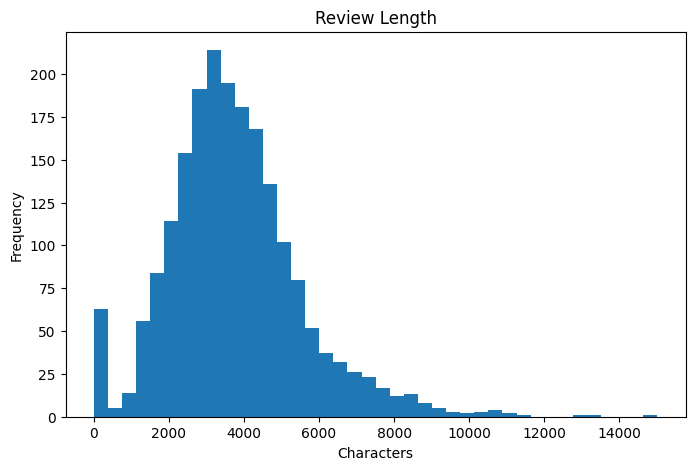

In [12]:
plt.figure(figsize=(8,5))

plt.hist(df['Review_Length'], bins=40)

plt.title("Review Length")

plt.xlabel("Characters")

plt.ylabel("Frequency")

plt.show()

In [14]:
#Text Preprocessing
stemmer = PorterStemmer()

In [15]:
stop_words = set(stopwords.words('english'))

In [16]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r'http\S+', '', text)

    text = re.sub(r'[^a-zA-Z]', ' ', text)

    words = text.split()

    words = [stemmer.stem(word)
             for word in words
             if word not in stop_words]

    return " ".join(words)

In [17]:
df['Clean_Review'] = df['review'].fillna('').apply(clean_text)
df[['review','Clean_Review']].head()

,review,Clean_Review
0,how do films like mouse hunt get into theatres...,film like mous hunt get theatr law someth diab...
1,some talented actresses are blessed with a dem...,talent actress bless demonstr wide act rang ot...
2,this has been an extraordinary year for austra...,extraordinari year australian film shine scoop...
3,according to hollywood movies made in last few...,accord hollywood movi made last decad life sma...
4,my first press screening of 1998 and already i...,first press screen alreadi gotten prime candid...


In [18]:
# Ensure the 'label' column is string type and clean it more robustly
# First, remove any non-alphabetic characters, then strip whitespace, and finally lowercase.
df['label'] = df['label'].astype(str).str.replace(r'[^a-zA-Z]', '', regex=True).str.strip().str.lower()

# Filter out rows where 'label' is not 'pos' or 'neg' after robust cleaning.
# This ensures that only valid labels are considered for mapping.
df = df[df['label'].isin(['pos', 'neg'])].copy() # .copy() to avoid SettingWithCopyWarning

# Now map 'pos' to 1 and 'neg' to 0.
# Since we've filtered, there should be no NaNs created by map here.
df['label'] = df['label'].map({
    'pos': 1,
    'neg': 0
})

# Convert the mapped 'label' column to integer type.
# At this point, there should be no NaNs in 'label' if the filtering was effective.
df['label'] = df['label'].astype(int)

In [19]:
#TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['Clean_Review'])

In [20]:
y = df['label']

In [21]:
#Train Test Split
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(

X,

y,

test_size=0.20,

random_state=42
)

In [22]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

lr.fit(X_train,y_train)

pred_lr = lr.predict(X_test)

In [23]:
from sklearn.metrics import accuracy_score

print("Accuracy =",accuracy_score(y_test,pred_lr))

Accuracy = 0.8475


In [24]:
#Naive Bayes
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()

nb.fit(X_train,y_train)

pred_nb = nb.predict(X_test)

print("Accuracy =",accuracy_score(y_test,pred_nb))

Accuracy = 0.8075


In [25]:
#Support Vector Machine
from sklearn.svm import LinearSVC

svm = LinearSVC()

svm.fit(X_train,y_train)

pred_svm = svm.predict(X_test)

print("Accuracy =",accuracy_score(y_test,pred_svm))

Accuracy = 0.85


In [26]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()

rf.fit(X_train,y_train)

pred_rf = rf.predict(X_test)

print("Accuracy =",accuracy_score(y_test,pred_rf))

Accuracy = 0.8225


In [27]:
#Compare Accuracy
accuracy = pd.DataFrame({

'Model':['Logistic Regression','Naive Bayes','SVM','Random Forest'],

'Accuracy':[

accuracy_score(y_test,pred_lr),

accuracy_score(y_test,pred_nb),

accuracy_score(y_test,pred_svm),

accuracy_score(y_test,pred_rf)

]

})

accuracy

,Model,Accuracy
0,Logistic Regression,0.8475
1,Naive Bayes,0.8075
2,SVM,0.8500
3,Random Forest,0.8225


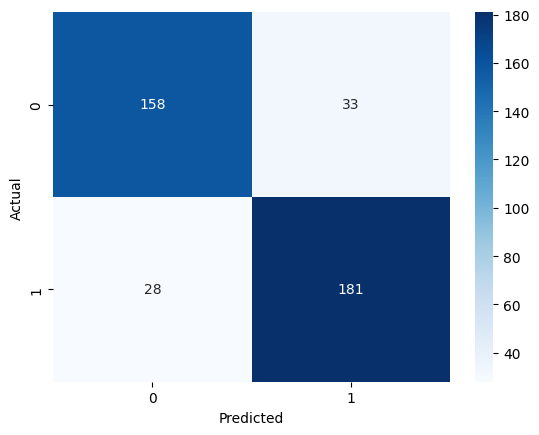

In [28]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,pred_lr)

sns.heatmap(cm,

annot=True,

fmt='d',

cmap='Blues')

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [29]:
#Classification Report
from sklearn.metrics import classification_report

print(classification_report(y_test,pred_lr))

              precision    recall  f1-score   support

           0       0.85      0.83      0.84       191
           1       0.85      0.87      0.86       209

    accuracy                           0.85       400
   macro avg       0.85      0.85      0.85       400
weighted avg       0.85      0.85      0.85       400



In [30]:
#Predict New Review
review = ["This movie is absolutely fantastic and wonderful."]

review = clean_text(review[0])

review = tfidf.transform([review])

prediction = lr.predict(review)

if prediction[0]==1:
    print("Positive Review")
else:
    print("Negative Review")

Positive Review


In [31]:
review = ["Worst movie I have ever seen. Waste of money."]

review = clean_text(review[0])

review = tfidf.transform([review])

prediction = lr.predict(review)

if prediction[0]==1:
    print("Positive Review")
else:
    print("Negative Review")

Negative Review
